<a href="https://colab.research.google.com/github/siminailie183/Background-removal-app/blob/main/tiatia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

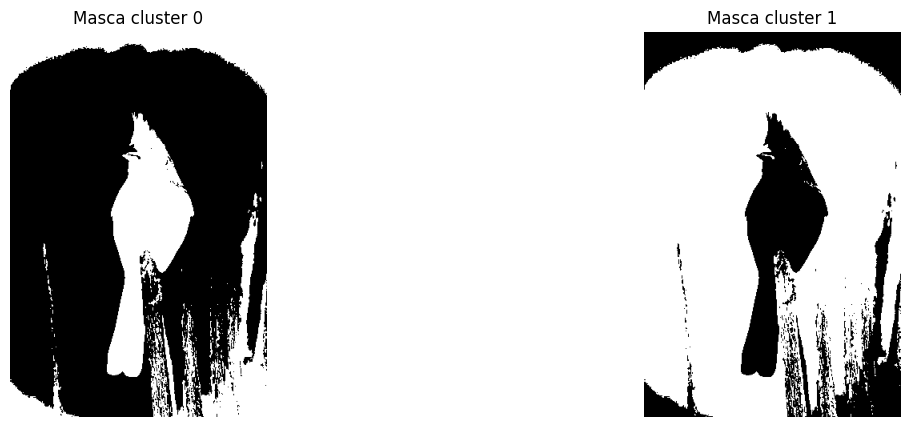

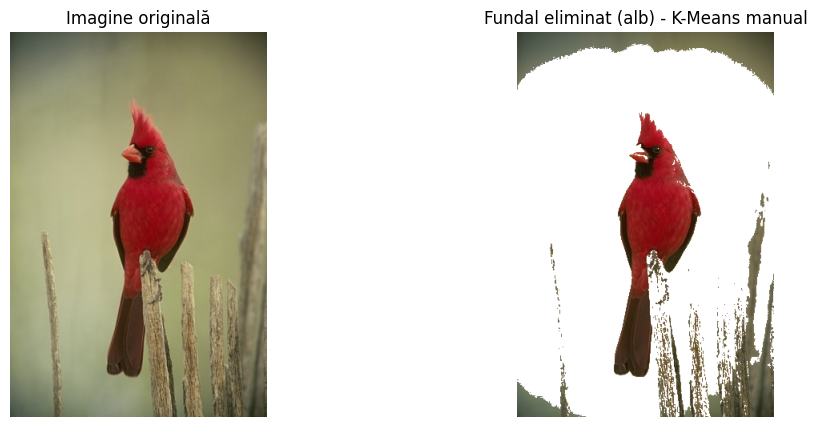

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# K MEANS implementat manual
def kmeans_manual(X, k=2, max_iters=30, tol=1e-4, seed=42):
    """
    X: (N, D) float32
    k: număr clustere
    Returneaza:
      labels: (N,) int
      centroids: (k, D) float32
    """
    rng = np.random.default_rng(seed)
    N, D = X.shape

    # 1) k puncte random
    centroids = X[rng.choice(N, size=k, replace=False)].copy()

    prev_inertia = None

    for _ in range(max_iters):
        # 2) calculam distanta euclidiana(patrata)
        distances = np.sum((X[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
        labels = np.argmin(distances, axis=1)

        # Inertia (suma distantelor minime)
        inertia = np.sum(np.min(distances, axis=1))

        # 3) recalculare centroid
        new_centroids = centroids.copy()
        for j in range(k):
            mask = (labels == j)
            if np.any(mask):
                new_centroids[j] = np.mean(X[mask], axis=0)
            else:
                new_centroids[j] = X[rng.integers(0, N)]

        # oprire: toleranta, inertie
        centroid_shift = np.sqrt(np.sum((new_centroids - centroids) ** 2))
        centroids = new_centroids

        if prev_inertia is not None:
            if abs(prev_inertia - inertia) / (prev_inertia + 1e-12) < tol:
                break

        if centroid_shift < 1e-3:
            break

        prev_inertia = inertia

    return labels.astype(np.int32), centroids.astype(np.float32)

img = cv2.imread("poza_pasare.jpg")
if img is None:
    raise ValueError("Imaginea nu a fost găsită. Verifică numele fișierului (ex: 'imagine.jpg').")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pixels = img.reshape((-1, 3)).astype(np.float32)

use_sampling = False
sample_size = 60000

k = 2
if use_sampling and pixels.shape[0] > sample_size:
    rng = np.random.default_rng(42)
    idx = rng.choice(pixels.shape[0], size=sample_size, replace=False)
    labels_sample, centroids = kmeans_manual(pixels[idx], k=k, max_iters=40, tol=1e-5, seed=42)

    distances_full = np.sum((pixels[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
    labels = np.argmin(distances_full, axis=1).astype(np.int32)
else:
    labels, centroids = kmeans_manual(pixels, k=k, max_iters=40, tol=1e-5, seed=42)

unique, counts = np.unique(labels, return_counts=True)
background_label = unique[np.argmax(counts)]

plt.figure(figsize=(15, 5))
for i in range(k):
    mask = (labels == i).reshape(img.shape[:2])
    plt.subplot(1, k, i + 1)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Masca cluster {i}")
    plt.axis("off")
plt.show()

mask_object = (labels != background_label).reshape(img.shape[:2])

result_white_bg = img.copy()
result_white_bg[~mask_object] = [255, 255, 255]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Imagine originală")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_white_bg)
plt.title("Fundal eliminat (alb) - K-Means manual")
plt.axis("off")

plt.show()


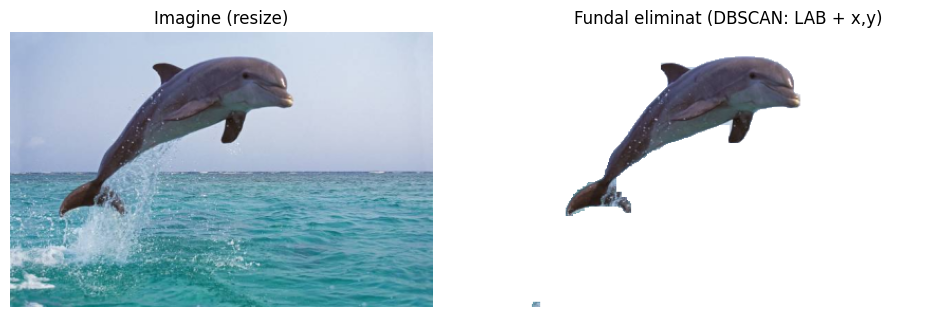

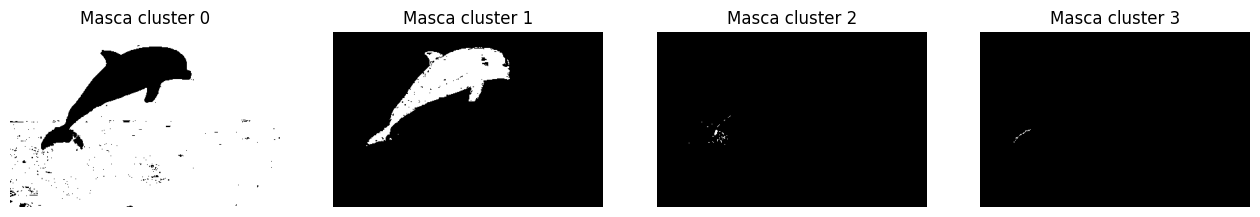

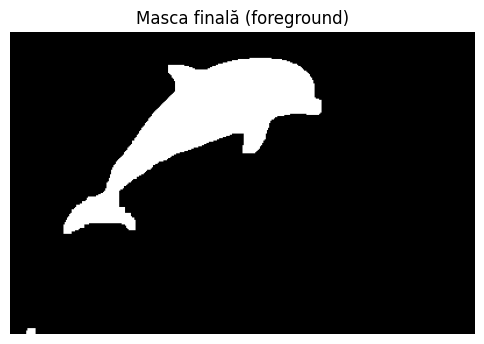

Parametri folosiți: {'eps': 0.35, 'min_samples': 30, 'pos_weight': 0.8}
Nr. clustere (fără noise): 4 | noise: 2490


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

path = "delfin2.jpg"
img_bgr = cv2.imread(path)
if img_bgr is None:
    raise ValueError("Imaginea nu a fost găsită. Verifică numele fișierului.")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

max_side = 400
h, w = img.shape[:2]
scale = min(1.0, max_side / max(h, w))
if scale < 1.0:
    img_small = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
else:
    img_small = img.copy()

Hs, Ws = img_small.shape[:2]

lab = cv2.cvtColor(img_small, cv2.COLOR_RGB2LAB).astype(np.float32)
L = lab[..., 0].reshape(-1, 1)
A = lab[..., 1].reshape(-1, 1)
B = lab[..., 2].reshape(-1, 1)

yy, xx = np.mgrid[0:Hs, 0:Ws]
X = xx.reshape(-1, 1).astype(np.float32)
Y = yy.reshape(-1, 1).astype(np.float32)

color = np.hstack([L, A, B])
pos = np.hstack([X, Y])

color_scaled = StandardScaler().fit_transform(color)

# pos_weight mai mare, clustere mai compacte spatial
pos_scaled = StandardScaler().fit_transform(pos)
pos_weight = 0.8
features = np.hstack([color_scaled, pos_scaled * pos_weight])

# 0.25 .. 0.8 eps
eps = 0.35
min_samples = 30

db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
labels = db.fit_predict(features).reshape(Hs, Ws)

border = np.zeros((Hs, Ws), dtype=bool)
border[0, :] = True; border[-1, :] = True; border[:, 0] = True; border[:, -1] = True

border_labels = labels[border]
border_labels = border_labels[border_labels != -1]
if border_labels.size == 0:
    raise ValueError("DBSCAN a marcat marginile ca noise. Încearcă eps mai mare (ex: 0.45) sau min_samples mai mic (ex: 10).")

vals, cnts = np.unique(border_labels, return_counts=True)
bg_label = vals[np.argmax(cnts)]

mask_fg = (labels != bg_label) & (labels != -1)
include_noise_as_fg = True
if include_noise_as_fg:
    mask_fg = (labels != bg_label)

# Mic post-procesare (umple gauri / curata)
mask_u8 = (mask_fg.astype(np.uint8) * 255)
kernel = np.ones((5,5), np.uint8)
mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel, iterations=1)
mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel, iterations=2)
mask_fg = mask_u8.astype(bool)

result_small = img_small.copy()
result_small[~mask_fg] = [255, 255, 255]

unique_labels = np.unique(labels)
to_show = [l for l in unique_labels if l != -1][:6]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(img_small); plt.title("Imagine (resize)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(result_small); plt.title("Fundal eliminat (DBSCAN: LAB + x,y)"); plt.axis("off")
plt.show()

if len(to_show) > 0:
    plt.figure(figsize=(4*len(to_show), 4))
    for i, l in enumerate(to_show):
        m = (labels == l)
        plt.subplot(1, len(to_show), i+1)
        plt.imshow(m, cmap="gray")
        plt.title(f"Masca cluster {l}")
        plt.axis("off")
    plt.show()

plt.figure(figsize=(6,6))
plt.imshow(mask_fg, cmap="gray")
plt.title("Masca finală (foreground)")
plt.axis("off")
plt.show()

print("Parametri folosiți:", {"eps": eps, "min_samples": min_samples, "pos_weight": pos_weight})
print("Nr. clustere (fără noise):", len([l for l in unique_labels if l != -1]), "| noise:", np.sum(labels==-1))

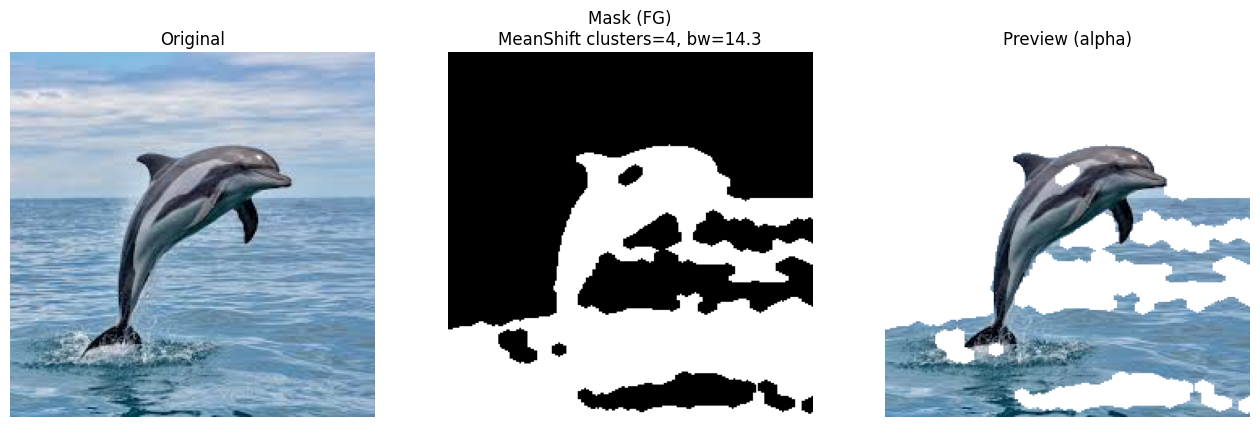

Saved: /content/nobg_meanshift.jpg | bg_clusters: [np.int64(0)]


In [ ]:
 #!pip -q install opencv-python scikit-learn

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift, estimate_bandwidth

INPUT_PATH = "/content/delfin.jpg"
OUTPUT_PATH = "/content/nobg_meanshift.jpg"

def remove_bg_meanshift(
    input_path: str,
    output_path: str,
    sample_pixels: int = 50_000,     # MeanShift e scump -> tine mic
    quantile: float = 0.9,          # pentru bandwidth (0.05..0.2)
    min_bg_frac: float = 0.06,       # clustere suficient de mari pot fi bg
    dist_thresh: float = 25.0,       # similaritate cu bg seed in Lab
    clean_mask: bool = True,
):
    bgr = cv2.imread(input_path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Nu pot citi: {input_path}")
    h, w = bgr.shape[:2]

    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    X = lab.reshape(-1, 3)

    n = X.shape[0]
    if n > sample_pixels:
        idx = np.random.choice(n, size=sample_pixels, replace=False)
        Xs = X[idx]
    else:
        idx = None
        Xs = X

    # bandwidth estimation on sample
    bw = estimate_bandwidth(Xs, quantile=quantile, n_samples=min(sample_pixels, Xs.shape[0]))
    if not np.isfinite(bw) or bw <= 0:
        bw = 30.0  # fallback safe-ish

    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    ms.fit(Xs)

    # Assign every pixel to nearest MeanShift center (simple)
    centers = ms.cluster_centers_  # (m,3)
    # distances (n_pixels, m) can be huge; do chunking
    labels_full = np.empty((X.shape[0],), dtype=np.int32)
    chunk = 200_000
    for start in range(0, X.shape[0], chunk):
        Xc = X[start:start+chunk]
        d = np.linalg.norm(Xc[:, None, :] - centers[None, :, :], axis=2)
        labels_full[start:start+chunk] = np.argmin(d, axis=1)

    labels = labels_full.reshape(h, w)
    m = centers.shape[0]

    counts = np.bincount(labels_full, minlength=m).astype(np.float64)
    fracs = counts / counts.sum()

    # bg seed = largest cluster
    bg_seed = int(np.argmax(counts))
    seed_center = centers[bg_seed]

    # include other big clusters similar in Lab
    candidates = np.where(fracs >= min_bg_frac)[0]
    dists = np.linalg.norm(centers - seed_center, axis=1)
    bg_clusters = candidates[dists[candidates] <= dist_thresh]
    if bg_clusters.size == 0:
        bg_clusters = np.array([bg_seed], dtype=int)

    fg_mask = (~np.isin(labels, bg_clusters)).astype(np.uint8) * 255

    if clean_mask:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel, iterations=1)
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

        num, cc, stats, _ = cv2.connectedComponentsWithStats((fg_mask > 0).astype(np.uint8), 8)
        if num > 1:
            keep = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            fg_mask = (cc == keep).astype(np.uint8) * 255

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgba = np.dstack([rgb, fg_mask])
    cv2.imwrite(output_path, cv2.cvtColor(rgba, cv2.COLOR_RGBA2BGRA))

    return rgb, labels, fg_mask, rgba, bw, centers.shape[0], bg_clusters

rgb, labels, mask, rgba, bw, n_clusters, bg_clusters = remove_bg_meanshift(
    INPUT_PATH,
    OUTPUT_PATH,
    sample_pixels=50_000,
    quantile=0.12,
    dist_thresh=25.0
)

plt.figure(figsize=(16,5))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(rgb); plt.axis("off")
plt.subplot(1,3,2); plt.title(f"Mask (FG)\nMeanShift clusters={n_clusters}, bw={bw:.1f}"); plt.imshow(mask, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Preview (alpha)"); plt.imshow(rgba); plt.axis("off")
plt.show()

print("Saved:", OUTPUT_PATH, "| bg_clusters:", list(bg_clusters))

In [ ]:
# !pip -q install opencv-python scikit-learn pandas

import cv2
import numpy as np
import time
import pandas as pd

from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


IMG_PATH = "/content/tucan.jpg"
N_SAMPLE = 25000
RANDOM_STATE = 42


K_KMEANS = 3

DB_EPS = 0.6
DB_MIN_SAMPLES = 12


MS_QUANTILE = 0.25
MS_MAX_SAMPLES_FOR_BW = 8000


bgr = cv2.imread(IMG_PATH, cv2.IMREAD_COLOR)
if bgr is None:
    raise FileNotFoundError(f"Nu pot citi imaginea: {IMG_PATH}")

lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
X = lab.reshape(-1, 3)

rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(X.shape[0], size=min(N_SAMPLE, X.shape[0]), replace=False)
Xs = X[idx]

scaler = StandardScaler()
Xs_scaled = scaler.fit_transform(Xs)

results = []

t0 = time.time()
km = KMeans(n_clusters=K_KMEANS, n_init="auto", random_state=RANDOM_STATE)
labels_km = km.fit_predict(Xs_scaled)
t_km = time.time() - t0

sil_km = silhouette_score(Xs_scaled, labels_km) if len(np.unique(labels_km)) > 1 else np.nan

results.append({
    "method": "KMeans",
    "clusters": int(len(np.unique(labels_km))),
    "silhouette": float(sil_km),
    "noise_frac": 0.0,
    "time_sec": float(t_km)
})

t0 = time.time()
db = DBSCAN(eps=DB_EPS, min_samples=DB_MIN_SAMPLES, n_jobs=-1)
labels_db = db.fit_predict(Xs_scaled)   # -1 = noise
t_db = time.time() - t0

noise_frac = float(np.mean(labels_db == -1))
non_noise = labels_db != -1
uniq_non_noise = np.unique(labels_db[non_noise])

if non_noise.sum() > 10 and len(uniq_non_noise) > 1:
    sil_db = silhouette_score(Xs_scaled[non_noise], labels_db[non_noise])
else:
    sil_db = np.nan

results.append({
    "method": "DBSCAN",
    "clusters": int(len(uniq_non_noise)),
    "silhouette": float(sil_db) if sil_db == sil_db else np.nan,
    "noise_frac": noise_frac,
    "time_sec": float(t_db)
})

bw_subset = Xs_scaled if Xs_scaled.shape[0] <= MS_MAX_SAMPLES_FOR_BW else Xs_scaled[:MS_MAX_SAMPLES_FOR_BW]

t0 = time.time()
bw = estimate_bandwidth(bw_subset, quantile=MS_QUANTILE, n_samples=bw_subset.shape[0])
if not np.isfinite(bw) or bw <= 0:
    bw = 1.0

ms = MeanShift(bandwidth=bw, bin_seeding=True)
labels_ms = ms.fit_predict(Xs_scaled)
t_ms = time.time() - t0

sil_ms = silhouette_score(Xs_scaled, labels_ms) if len(np.unique(labels_ms)) > 1 else np.nan

results.append({
    "method": "MeanShift",
    "clusters": int(len(np.unique(labels_ms))),
    "silhouette": float(sil_ms),
    "noise_frac": 0.0,
    "time_sec": float(t_ms),
    "bandwidth": float(bw)
})


df = pd.DataFrame(results)
df["silhouette"] = df["silhouette"].round(4)
df["noise_frac"] = (df["noise_frac"] * 100).round(2)
df["time_sec"] = df["time_sec"].round(3)
if "bandwidth" in df.columns:
    df["bandwidth"] = df["bandwidth"].round(3)

print(df.to_string(index=False))

print("\nNote:")
print("- Silhouette e calculat pe acelasi sample de pixeli (Lab standardizat).")
print("- La DBSCAN, Silhouette e calculat DOAR pe punctele non-noise (label != -1).")
print("- DBSCAN are parametri sensibili: eps/min_samples schimba mult nr. de clustere si % noise.")

   method  clusters  silhouette  noise_frac  time_sec  bandwidth
   KMeans         3      0.5862         0.0     0.281        NaN
   DBSCAN         3      0.7178         0.6     6.693        NaN
MeanShift        16      0.4631         0.0     7.754      1.179

Note:
- Silhouette e calculat pe acelasi sample de pixeli (Lab standardizat).
- La DBSCAN, Silhouette e calculat DOAR pe punctele non-noise (label != -1).
- DBSCAN are parametri sensibili: eps/min_samples schimba mult nr. de clustere si % noise.
